In [1]:
import requests
# from config import OPEN_WEATHER_API_KEY
OPEN_WEATHER_API_KEY="18b9edf4dbc84d01f9f78e0f18eeb8e3"

def fetch_weather_now(city_name, country_code):
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city_name},{country_code}&units=metric&appid={OPEN_WEATHER_API_KEY}"
    response = requests.get(url)
    
    if response.status_code != 200:
        raise Exception(f"Weather API failed with status {response.status_code}")

    # print(f"Weather API Response: {response.json()}")  # Debugging line
    return response.json()

def fetch_weather_forecast(city_name, country_code, cnt=7):
    url = f"http://api.openweathermap.org/data/2.5/forecast/daily?q={city_name},{country_code}&units=metric&cnt={cnt}&appid={OPEN_WEATHER_API_KEY}"
    response = requests.get(url)

    if response.status_code != 200:
        raise Exception(f"Weather Forecast API failed with status {response.status_code}")

    return response.json()

# if __name__ == "__main__":
#     # Example usage
#     lat = 37.7749
#     lon = -122.4194
#     df = fetch_weather_forecast(lat, lon)
#     print(df)

In [4]:
lat = 37.7749
lon = -122.4194
df = fetch_weather_now("Katihar", "IN")
print(df)

{'coord': {'lon': 87.5833, 'lat': 25.5333}, 'weather': [{'id': 803, 'main': 'Clouds', 'description': 'broken clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 36.12, 'feels_like': 40.89, 'temp_min': 36.12, 'temp_max': 36.12, 'pressure': 998, 'humidity': 44, 'sea_level': 998, 'grnd_level': 995}, 'visibility': 10000, 'wind': {'speed': 2.58, 'deg': 132, 'gust': 2.6}, 'clouds': {'all': 53}, 'dt': 1755335148, 'sys': {'country': 'IN', 'sunrise': 1755301406, 'sunset': 1755348288}, 'timezone': 19800, 'id': 1267480, 'name': 'Katihar', 'cod': 200}


In [5]:
df.keys()

dict_keys(['coord', 'weather', 'base', 'main', 'visibility', 'wind', 'clouds', 'dt', 'sys', 'timezone', 'id', 'name', 'cod'])

In [6]:
df.get('list')

In [2]:
import pandas as pd

def clean_weather_forecast(raw_list):
    """Convert OneCall daily forecast list into a clean DataFrame."""
    records = []
    for entry in raw_list:
        record = {
            "date": pd.to_datetime(entry["dt"], unit="s").normalize(),
            "sunrise": pd.to_datetime(entry.get("sunrise"), unit="s"),
            "sunset": pd.to_datetime(entry.get("sunset"), unit="s"),

            # temps
            "temp_day": entry["temp"].get("day"),
            "temp_min": entry["temp"].get("min"),
            "temp_max": entry["temp"].get("max"),
            "temp_night": entry["temp"].get("night"),
            "temp_eve": entry["temp"].get("eve"),
            "temp_morn": entry["temp"].get("morn"),

            # feels_like
            "feels_day": entry["feels_like"].get("day"),
            "feels_night": entry["feels_like"].get("night"),
            "feels_eve": entry["feels_like"].get("eve"),
            "feels_morn": entry["feels_like"].get("morn"),

            # other
            "pressure": entry.get("pressure"),
            "humidity": entry.get("humidity"),
            "clouds": entry.get("clouds"),
            "pop": entry.get("pop"),
            "rain": entry.get("rain", 0),

            # wind
            "wind_speed": entry.get("speed"),
            "wind_deg": entry.get("deg"),
            "wind_gust": entry.get("gust"),

            # weather
            "weather_main": entry["weather"][0].get("main") if entry.get("weather") else None,
            "weather_desc": entry["weather"][0].get("description") if entry.get("weather") else None,
        }
        records.append(record)

    df = pd.DataFrame(records)
    df.set_index("date", inplace=True)
    return df

In [3]:
df_forecast = clean_weather_forecast(fetch_weather_forecast("Katihar", "IN").get("list"))

In [4]:
df_forecast

,sunrise,sunset,temp_day,temp_min,temp_max,temp_night,temp_eve,temp_morn,feels_day,feels_night,...,pressure,humidity,clouds,pop,rain,wind_speed,wind_deg,wind_gust,weather_main,weather_desc
date,,,,,,,,,,,,,,,,,,,,,
2025-08-16,2025-08-15 23:43:26,2025-08-16 12:44:48,33.35,26.65,36.11,30.29,32.02,26.92,38.62,34.76,...,1002,55,9,0.00,0.00,3.49,185,5.53,Clear,sky is clear
2025-08-17,2025-08-16 23:43:54,2025-08-17 12:43:57,34.89,28.32,35.80,29.07,33.23,28.40,41.20,34.29,...,1003,52,5,0.89,2.02,5.14,115,7.55,Rain,light rain
2025-08-18,2025-08-17 23:44:21,2025-08-18 12:43:06,32.75,26.94,35.19,30.04,34.59,27.24,37.88,35.38,...,1006,57,99,1.00,5.75,3.66,156,7.83,Rain,moderate rain
2025-08-19,2025-08-18 23:44:47,2025-08-19 12:42:13,33.52,27.08,34.63,28.24,32.58,27.29,39.38,32.21,...,1004,56,92,0.76,1.41,5.92,121,8.98,Rain,light rain
2025-08-20,2025-08-19 23:45:14,2025-08-20 12:41:19,31.84,26.66,32.19,27.49,30.16,26.66,36.70,31.50,...,1002,60,59,0.91,2.35,5.94,115,8.44,Rain,light rain
2025-08-21,2025-08-20 23:45:40,2025-08-21 12:40:25,32.49,25.68,32.55,27.10,29.73,25.68,38.92,30.69,...,1001,62,82,1.00,15.71,5.51,125,8.09,Rain,moderate rain
2025-08-22,2025-08-21 23:46:06,2025-08-22 12:39:30,32.00,25.82,32.00,26.97,29.26,25.82,38.33,30.55,...,1000,64,100,1.00,26.55,5.59,94,8.72,Rain,moderate rain


In [5]:
df_forecast.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7 entries, 2025-08-16 to 2025-08-22
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   sunrise       7 non-null      datetime64[ns]
 1   sunset        7 non-null      datetime64[ns]
 2   temp_day      7 non-null      float64       
 3   temp_min      7 non-null      float64       
 4   temp_max      7 non-null      float64       
 5   temp_night    7 non-null      float64       
 6   temp_eve      7 non-null      float64       
 7   temp_morn     7 non-null      float64       
 8   feels_day     7 non-null      float64       
 9   feels_night   7 non-null      float64       
 10  feels_eve     7 non-null      float64       
 11  feels_morn    7 non-null      float64       
 12  pressure      7 non-null      int64         
 13  humidity      7 non-null      int64         
 14  clouds        7 non-null      int64         
 15  pop           7 non-nul

In [13]:
import matplotlib.pyplot as plt

def plot_weather_forecast(df):
    plt.figure(figsize=(12, 6))
    
    plt.plot(df.index, df["temp_day"], marker="o", label="Day Temp (°C)")
    plt.plot(df.index, df["temp_min"], marker="s", label="Min Temp (°C)")
    plt.plot(df.index, df["temp_max"], marker="^", label="Max Temp (°C)")
    plt.plot(df.index, df["temp_night"], marker="x", label="Night Temp (°C)")
    plt.plot(df.index, df["temp_eve"], marker="d", label="Evening Temp (°C)")
    plt.plot(df.index, df["temp_morn"], marker="p", label="Morning Temp (°C)")
    
    plt.title("7-Day Weather Forecast: Temperature Trends")
    plt.xlabel("Date")
    plt.ylabel("Temperature (°C)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

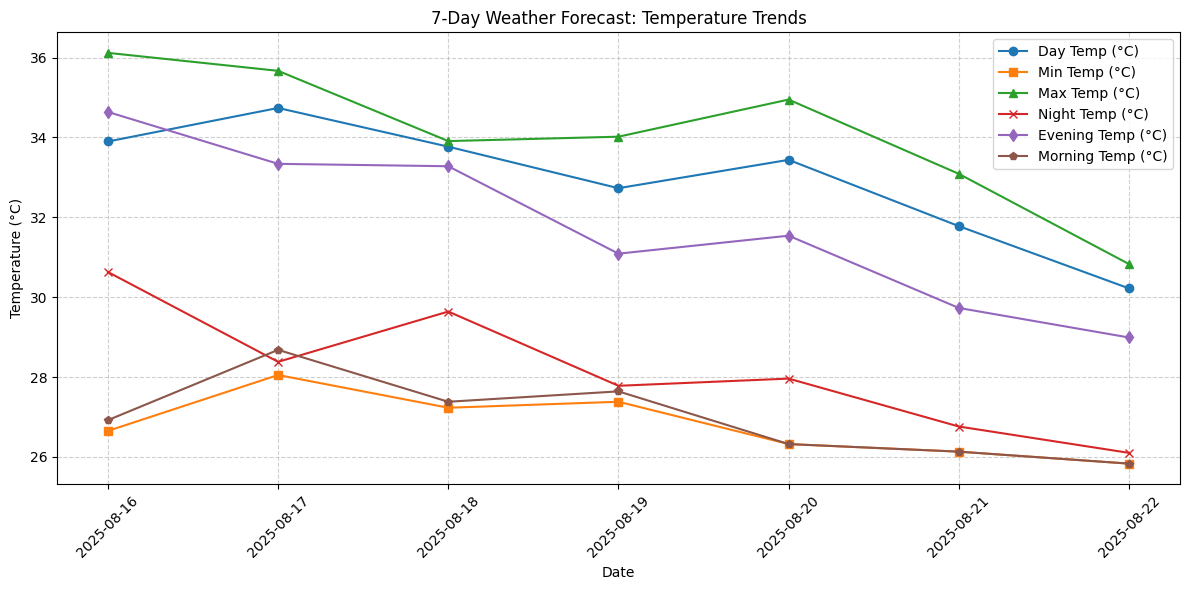

In [14]:
plot_weather_forecast(df_forecast)

In [15]:
import matplotlib.pyplot as plt

def plot_rain_forecast(df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

    # Rainfall bar plot
    axes[0].bar(df.index, df["rain"], alpha=0.6, color="blue", label="Rainfall (mm)")
    axes[0].set_ylabel("Rainfall (mm)")
    axes[0].set_title("Rainfall Forecast (7 Days)")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)

    # Precipitation probability line plot
    axes[1].plot(df.index, df["pop"] * 100, color="red", marker="o", label="Precipitation Probability (%)")
    axes[1].set_ylabel("Probability (%)")
    axes[1].set_title("Precipitation Probability Forecast (7 Days)")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)

    # Rotate x-axis labels for both plots
    for ax in axes:
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    fig.suptitle("Rain & Precipitation Forecast (7 Days)", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

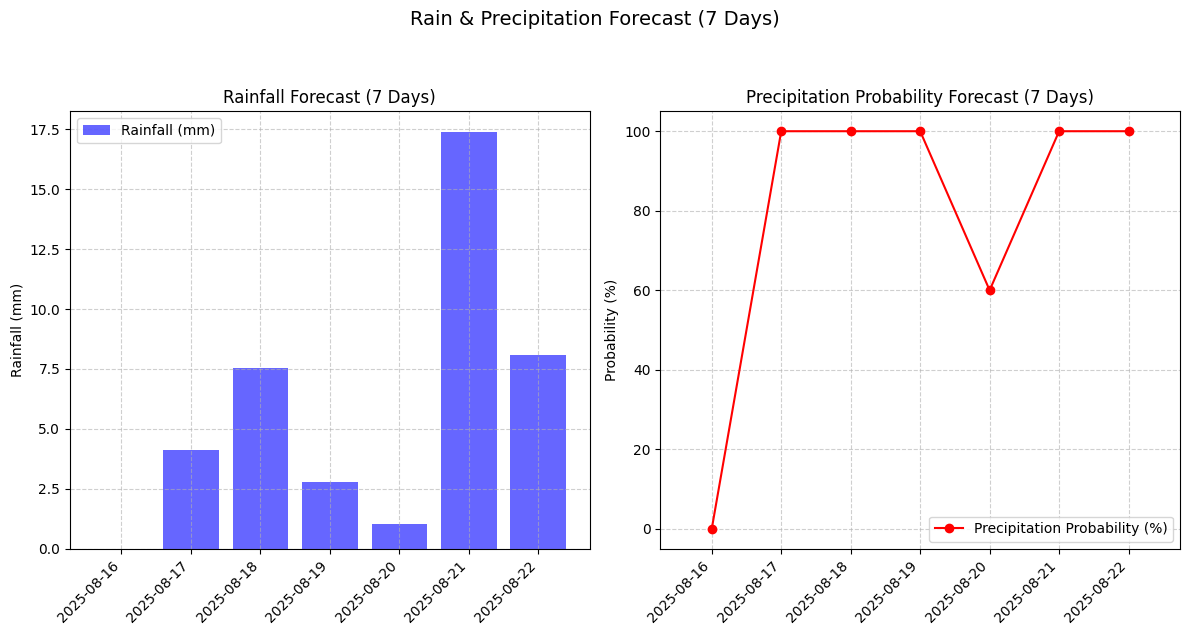

In [16]:
plot_rain_forecast(df_forecast)

In [17]:
def plot_wind_forecast(df):
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df["wind_speed"], marker="o", label="Wind Speed (m/s)")
    plt.plot(df.index, df["wind_gust"], marker="^", linestyle="--", label="Wind Gust (m/s)")
    
    plt.title("Wind Forecast (7 Days)")
    plt.xlabel("Date")
    plt.ylabel("Speed (m/s)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

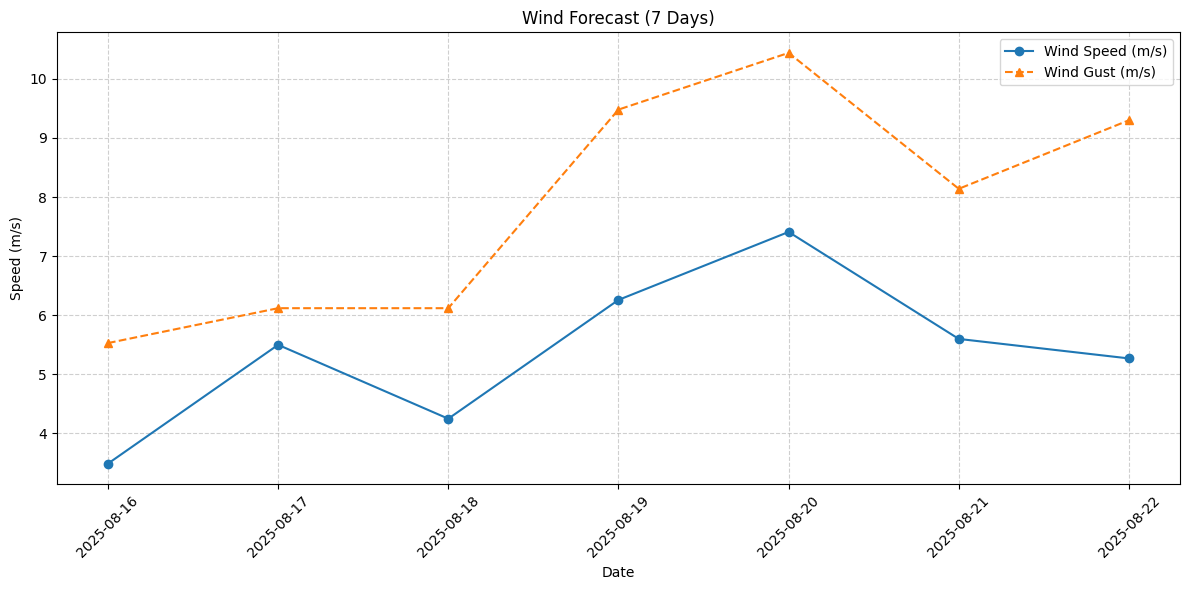

In [18]:
plot_wind_forecast(df_forecast)

In [6]:
import pandas as pd

def clean_weather_now(raw: dict) -> pd.DataFrame:
    record = {
        "city": raw.get("name"),
        "country": raw.get("sys", {}).get("country"),
        "dt": pd.to_datetime(raw.get("dt"), unit="s"),
        "timezone": raw.get("timezone"),

        # main metrics
        "temp": raw["main"].get("temp"),
        "feels_like": raw["main"].get("feels_like"),
        "temp_min": raw["main"].get("temp_min"),
        "temp_max": raw["main"].get("temp_max"),
        "pressure": raw["main"].get("pressure"),
        "humidity": raw["main"].get("humidity"),

        # wind
        "wind_speed": raw["wind"].get("speed"),
        "wind_deg": raw["wind"].get("deg"),
        "wind_gust": raw["wind"].get("gust"),

        # clouds/visibility
        "clouds": raw.get("clouds", {}).get("all"),
        "visibility": raw.get("visibility"),

        # weather desc
        "weather_main": raw["weather"][0].get("main") if raw.get("weather") else None,
        "weather_desc": raw["weather"][0].get("description") if raw.get("weather") else None,

        # sunrise/sunset
        "sunrise": pd.to_datetime(raw["sys"].get("sunrise"), unit="s"),
        "sunset": pd.to_datetime(raw["sys"].get("sunset"), unit="s"),
    }

    df = pd.DataFrame([record])
    df.set_index("dt", inplace=True)
    return df

In [7]:
df_current = clean_weather_now(fetch_weather_now("Katihar", "IN"))

In [23]:
df_current

,city,country,timezone,temp,feels_like,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,wind_gust,clouds,visibility,weather_main,weather_desc,sunrise,sunset
dt,,,,,,,,,,,,,,,,,,
2025-08-16 14:42:00,Katihar,IN,19800,30.44,34.85,30.44,30.44,1001,65,2.7,167,4.01,44,10000,Clouds,scattered clouds,2025-08-15 23:43:26,2025-08-16 12:44:48


In [11]:
import requests

def fetch_air_now(lat, lon):
    url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={OPEN_WEATHER_API_KEY}"
    response = requests.get(url)
    
    if response.status_code != 200:
        raise Exception(f"AQI API failed with status {response.status_code}")
    return response.json()

def fetch_air_forecast(lat, lon, cnt=7):
    url = f"http://api.openweathermap.org/data/2.5/air_pollution/forecast?lat={lat}&lon={lon}&cnt={cnt}&appid={OPEN_WEATHER_API_KEY}"
    response = requests.get(url)

    if response.status_code != 200:
        raise Exception(f"AQI Forecast API failed with status {response.status_code}")

    return response.json()

In [12]:
def get_city_coordinates(city_name, country_code):
    url = f"http://api.openweathermap.org/geo/1.0/direct?q={city_name},{country_code}&limit=1&appid={OPEN_WEATHER_API_KEY}"
    response = requests.get(url)
    
    if response.status_code != 200:
        raise Exception(f"Geocoding API failed with status {response.status_code}")
    
    data = response.json()
    if not data or "lat" not in data[0] or "lon" not in data[0]:
        raise Exception("No geocoding data returned from API")
    
    # print(f"Geocoding API Response: {data}")  # Debugging line
    return {
        "lat": data[0]["lat"],
        "lon": data[0]["lon"]
    }

In [13]:
coords = get_city_coordinates("Katihar", "IN")
coords

{'lat': 25.5433817, 'lon': 87.5690417}

In [14]:
fetch_air_now(coords['lat'], coords['lon'])

{'coord': {'lon': 87.569, 'lat': 25.5434},
 'list': [{'main': {'aqi': 3},
   'components': {'co': 260.57,
    'no': 0,
    'no2': 9.78,
    'o3': 62.04,
    'so2': 11.66,
    'pm2_5': 29.11,
    'pm10': 33.21,
    'nh3': 2.54},
   'dt': 1755355826}]}

In [15]:
fetch_air_forecast(coords['lat'], coords['lon'])

{'coord': {'lon': 87.569, 'lat': 25.5434},
 'list': [{'main': {'aqi': 3},
   'components': {'co': 236.82,
    'no': 0,
    'no2': 8.35,
    'o3': 71.81,
    'so2': 10.51,
    'pm2_5': 28.41,
    'pm10': 31.72,
    'nh3': 2.36},
   'dt': 1755352800},
  {'main': {'aqi': 3},
   'components': {'co': 260.57,
    'no': 0,
    'no2': 9.78,
    'o3': 62.04,
    'so2': 11.66,
    'pm2_5': 29.11,
    'pm10': 33.21,
    'nh3': 2.54},
   'dt': 1755356400},
  {'main': {'aqi': 3},
   'components': {'co': 279.19,
    'no': 0,
    'no2': 10.94,
    'o3': 52.12,
    'so2': 12.35,
    'pm2_5': 29.39,
    'pm10': 34.11,
    'nh3': 2.45},
   'dt': 1755360000},
  {'main': {'aqi': 3},
   'components': {'co': 299.49,
    'no': 0,
    'no2': 11.98,
    'o3': 43.69,
    'so2': 12.51,
    'pm2_5': 30.22,
    'pm10': 35.53,
    'nh3': 2.32},
   'dt': 1755363600},
  {'main': {'aqi': 3},
   'components': {'co': 312.59,
    'no': 0,
    'no2': 12.59,
    'o3': 36.73,
    'so2': 12.11,
    'pm2_5': 31.14,
    'pm10'

In [16]:
import pandas as pd
from datetime import datetime, timezone

def clean_air_data(data):
    records = []
    for entry in data:
        record = {
            "datetime": datetime.fromtimestamp(entry["dt"]),
            "aqi_index": entry["main"]["aqi"],   # renamed for clarity
            "co": entry["components"]["co"],
            "no": entry["components"]["no"],
            "no2": entry["components"]["no2"],
            "o3": entry["components"]["o3"],
            "so2": entry["components"]["so2"],
            "pm2_5": entry["components"]["pm2_5"],
            "pm10": entry["components"]["pm10"],
            "nh3": entry["components"]["nh3"],
        }
        records.append(record)

    df = pd.DataFrame(records).set_index("datetime")
    
    # attach units metadata
    df.attrs["units"] = {
        "co": "µg/m³", "no": "µg/m³", "no2": "µg/m³", "o3": "µg/m³",
        "so2": "µg/m³", "pm2_5": "µg/m³", "pm10": "µg/m³", "nh3": "µg/m³",
        "aqi_index": "1–5 scale"
    }
    
    return df

In [21]:
df = clean_air_data(fetch_air_now(coords['lat'], coords['lon']).get('list'))
df

,aqi_index,co,no,no2,o3,so2,pm2_5,pm10,nh3
datetime,,,,,,,,,
2025-08-16 20:20:26,3,260.57,0,9.78,62.04,11.66,29.11,33.21,2.54


In [63]:
df = clean_air_data(fetch_air_forecast(coords['lat'], coords['lon']).get('list'))
df

,aqi_index,co,no,no2,o3,so2,pm2_5,pm10,nh3
datetime,,,,,,,,,
2025-08-16 14:30:00,2,200.51,1.00,5.46,67.53,6.62,23.21,24.49,0.05
2025-08-16 15:30:00,3,203.79,0.57,4.18,81.69,6.60,28.76,30.26,0.43
2025-08-16 16:30:00,3,215.95,0.40,4.56,84.97,7.13,31.92,33.86,1.26
2025-08-16 17:30:00,3,231.06,0.22,6.22,81.83,8.03,32.34,34.73,1.96
2025-08-16 18:30:00,3,246.87,0.02,7.83,74.37,8.40,31.88,34.90,2.58
...,...,...,...,...,...,...,...,...,...
2025-08-20 09:30:00,2,275.29,5.10,10.59,28.02,12.78,21.41,25.87,1.01
2025-08-20 10:30:00,2,260.50,4.44,10.41,37.26,13.36,22.57,26.72,0.93
2025-08-20 11:30:00,3,251.22,3.42,10.04,48.32,14.05,26.48,30.53,0.82


In [68]:
import matplotlib.pyplot as plt

def plot_air_data(df):
    plt.figure(figsize=(10, 6))
    plt.plot(df.index, df["pm2_5"], label="PM2.5", marker="o")
    plt.plot(df.index, df["pm10"], label="PM10", marker="s")
    plt.plot(df.index, df["no2"], label="NO2", marker="^")
    plt.plot(df.index, df["co"], label="CO", marker="x")
    plt.plot(df.index, df["o3"], label="O3", marker="d")
    plt.plot(df.index, df["so2"], label="SO2", marker="p")

    plt.title("Air Quality Forecast (7 days)")
    plt.xlabel("Datetime")
    plt.ylabel("Concentration (µg/m³)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

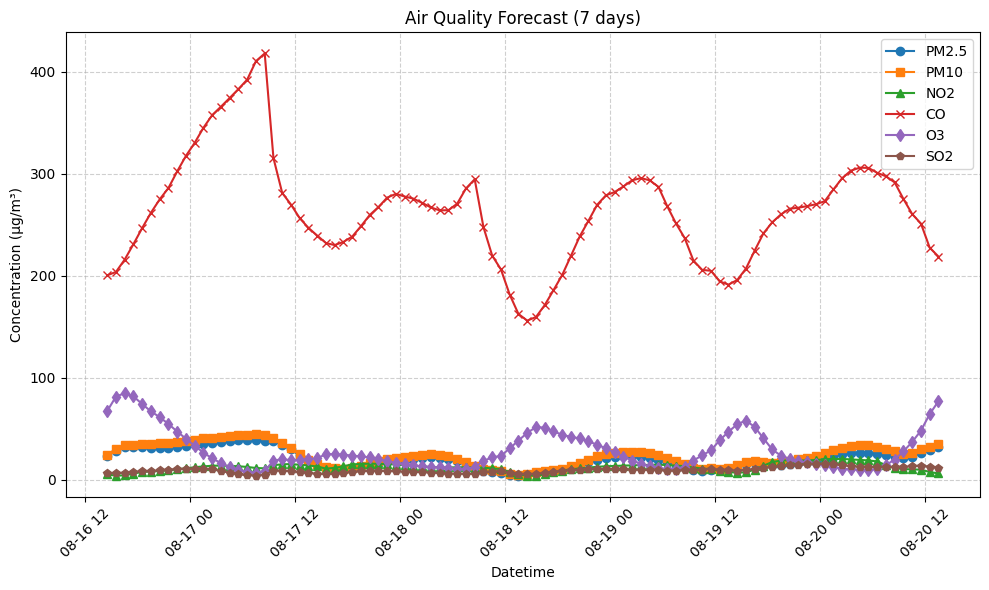

In [69]:
plot_air_data(df)